<a href="https://colab.research.google.com/github/Amthi/NLP_/blob/main/DIVYA_DIWAKAR_NLP_Customer_Feedback_NLP_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Feedback NLP Pipeline
### Sentiment Analysis, Complaint Classification, Semantic Retrieval, Transformer Fine-Tuning and Responsible NLP

**Dataset:** Twitter US Airline Sentiment (Crowdflower / Figure Eight, February 2015)
**Direct dataset link:** https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment
**Mirror used to fetch the raw CSV in this notebook:** https://github.com/fastforwardlabs/airline-sentiment (`data/Tweets.csv`)

This notebook is structured to run top-to-bottom in Google Colab. Runtime → Change runtime type → GPU is recommended for Task 4 (transformer fine-tuning).

```
!pip install -q nltk spacy gensim wordcloud transformers torch scikit-learn
!python -m spacy download en_core_web_sm
```


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Task 1 — Preprocessing and Exploratory Analysis for Customer Feedback Inputs

In [2]:
import re, json, time, random
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

random.seed(42); np.random.seed(42)
sns.set_style("whitegrid")

df = pd.read_csv("/content/drive/MyDrive/Tweets.csv")
df = df[['tweet_id','airline_sentiment','airline','negativereason','text','retweet_count']].dropna(subset=['text','airline_sentiment'])
print("Shape:", df.shape)
print(df['airline_sentiment'].value_counts())
print(df.head(3).to_string())

# ---------- Basic cleaning ----------
def basic_clean(t):
    t = str(t)
    t = re.sub(r'http\S+|www\.\S+', ' ', t)         # urls
    t = re.sub(r'@\w+', ' ', t)                      # mentions
    t = re.sub(r'#(\w+)', r'\1', t)                  # hashtags -> keep word
    t = re.sub(r'[^A-Za-z\s\']', ' ', t)             # punctuation/numbers
    t = re.sub(r'\s+', ' ', t).strip().lower()
    return t

df['clean_text'] = df['text'].apply(basic_clean)
df['review_len'] = df['text'].apply(lambda x: len(str(x).split()))
df.to_csv("/content/drive/MyDrive/df_clean.csv", index=False)
print(df[['text','clean_text']].head(5).to_string())

# ---------- Visualisation 1: sentiment distribution ----------
plt.figure(figsize=(6,4))
order = df['airline_sentiment'].value_counts().index
ax = sns.countplot(data=df, x='airline_sentiment', order=order, palette='viridis')
plt.title("Distribution of Customer Sentiment Classes")
plt.xlabel("Sentiment"); plt.ylabel("Number of Tweets")
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x()+p.get_width()/2, p.get_height()), ha='center', va='bottom')
plt.tight_layout();
plt.savefig("/content/drive/MyDrive/figs/01_sentiment_dist.png", dpi=140);
plt.close()

# ---------- Visualisation 2: review length distribution ----------
plt.figure(figsize=(6,4))
sns.histplot(df['review_len'], bins=30, kde=True, color='teal')
plt.title("Distribution of Review (Tweet) Length in Words")
plt.xlabel("Number of Words"); plt.ylabel("Frequency")
plt.tight_layout(); plt.savefig("/content/drive/MyDrive/figs/02_review_length.png", dpi=140); plt.close()

# ---------- Visualisation 3: sentiment by airline ----------
plt.figure(figsize=(8,4.5))
sns.countplot(data=df, x='airline', hue='airline_sentiment', order=df['airline'].value_counts().index, palette='rocket')
plt.title("Sentiment Breakdown by Airline")
plt.xlabel("Airline"); plt.ylabel("Count"); plt.xticks(rotation=20)
plt.legend(title='Sentiment')
plt.tight_layout();
plt.savefig("/content/drive/MyDrive/figs/03_sentiment_by_airline.png", dpi=140);
plt.close()

# ---------- Visualisation 4: top negative reasons ----------
plt.figure(figsize=(7,5))
neg_reason = df['negativereason'].value_counts().head(10)
sns.barplot(x=neg_reason.values, y=neg_reason.index, palette='mako')
plt.title("Top 10 Complaint Themes (Negative Reasons)")
plt.xlabel("Number of Tweets"); plt.ylabel("Complaint Theme")
plt.tight_layout(); plt.savefig("/content/drive/MyDrive/figs/04_negative_reasons.png", dpi=140); plt.close()
print("\nTop negative reasons:\n", neg_reason)

print("\nTask 1a (loading, cleaning, EDA charts) complete.")


Shape: (14640, 6)
airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64
             tweet_id airline_sentiment         airline negativereason                                                                      text  retweet_count
0  570306133677760513           neutral  Virgin America            NaN                                       @VirginAmerica What @dhepburn said.              0
1  570301130888122368          positive  Virgin America            NaN  @VirginAmerica plus you've added commercials to the experience... tacky.              0
2  570301083672813571           neutral  Virgin America            NaN   @VirginAmerica I didn't today... Must mean I need to take another trip!              0
                                                                                                                             text                                                                                                   clean_text
0       

/tmp/ipykernel_2873/1868740575.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='airline_sentiment', order=order, palette='viridis')
/tmp/ipykernel_2873/1868740575.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=neg_reason.values, y=neg_reason.index, palette='mako')



Top negative reasons:
 negativereason
Customer Service Issue         2910
Late Flight                    1665
Can't Tell                     1190
Cancelled Flight                847
Lost Luggage                    724
Bad Flight                      580
Flight Booking Problems         529
Flight Attendant Complaints     481
longlines                       178
Damaged Luggage                  74
Name: count, dtype: int64

Task 1a (loading, cleaning, EDA charts) complete.


### NLTK vs spaCy: tokenisation, lemmatisation, NER

In [3]:
import re, time, json
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import spacy

df = pd.read_csv("/content/drive/MyDrive/out/df_clean.csv")
sample = df.sample(2000, random_state=42).reset_index(drop=True)   # manageable subset for NER/spaCy pass
sample.to_csv("/content/drive/MyDrive/out/sample2000.csv", index=False)

# ================= NLTK PIPELINE =================
nltk.download('stopwords') # Fix: Download NLTK stopwords corpus
nltk.download('punkt') # Fix: Download NLTK punkt_tab corpus, which is part of the 'punkt' package
nltk.download('punkt_tab') # Fix: Explicitly download punkt_tab as per error message
nltk.download('wordnet') # Fix: Download NLTK wordnet corpus for lemmatization
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def nltk_pipeline(text):
    tokens = word_tokenize(text)
    tokens_nostop = [t for t in tokens if t not in stop_words and len(t) > 1]
    lemmas = [lemmatizer.lemmatize(t, pos='v') for t in tokens_nostop]
    lemmas = [lemmatizer.lemmatize(t, pos='n') for t in lemmas]
    return tokens, tokens_nostop, lemmas

t0 = time.time()
nltk_tokens_all, nltk_nostop_all, nltk_lemmas_all = [], [], []
for txt in sample['clean_text']:
    tk, ns, lm = nltk_pipeline(txt)
    nltk_tokens_all.append(tk); nltk_nostop_all.append(ns); nltk_lemmas_all.append(lm)
nltk_time = time.time() - t0

sample['nltk_tokens'] = nltk_tokens_all
sample['nltk_tokens_nostop'] = nltk_nostop_all
sample['nltk_lemmas'] = nltk_lemmas_all

nltk_total_tokens = sum(len(t) for t in nltk_tokens_all)
nltk_vocab = set(w for doc in nltk_lemmas_all for w in doc)

print("NLTK pipeline time: %.2fs" % nltk_time)
print("NLTK total tokens (raw):", nltk_total_tokens)
print("NLTK vocab size (post lemma, post stopword):", len(nltk_vocab))

# ================= spaCy PIPELINE =================
nlp = spacy.load("en_core_web_sm", disable=["parser"])
t0 = time.time()
spacy_lemmas_all, spacy_tokens_all, spacy_entities_all = [], [], []
docs = list(nlp.pipe(sample['clean_text'].tolist(), batch_size=64))
for doc in docs:
    toks = [tok.text for tok in doc]
    lemmas = [tok.lemma_ for tok in doc if not tok.is_stop and not tok.is_punct and len(tok.text) > 1]
    ents = [(ent.text, ent.label_) for ent in doc.ents]
    spacy_tokens_all.append(toks); spacy_lemmas_all.append(lemmas); spacy_entities_all.append(ents)
spacy_time = time.time() - t0

sample['spacy_lemmas'] = spacy_lemmas_all
sample['spacy_entities'] = spacy_entities_all

spacy_total_tokens = sum(len(t) for t in spacy_tokens_all)
spacy_vocab = set(w for doc in spacy_lemmas_all for w in doc)

print("\nspaCy pipeline time: %.2fs" % spacy_time)
print("spaCy total tokens (raw):", spacy_total_tokens)
print("spaCy vocab size (post lemma, post stop/punct removal):", len(spacy_vocab))

# ---------- NER aggregate ----------
all_ents = [e for doc_ents in spacy_entities_all for e in doc_ents]
ent_labels = Counter([lab for _, lab in all_ents])
print("\nEntity type frequency (spaCy NER, sample of 2000 tweets):")
print(ent_labels.most_common())

# save a few concrete entity examples per common label
examples_by_label = {}
for text, lab in all_ents:
    examples_by_label.setdefault(lab, [])
    if len(examples_by_label[lab]) < 5 and text.strip() not in examples_by_label[lab]:
        examples_by_label[lab].append(text.strip())

print("\nSample entities by type:")
for lab, exs in sorted(examples_by_label.items(), key=lambda x: -ent_labels[x[0]]):
    print(f"  {lab} ({ent_labels[lab]}): {exs}")

# ---------- Lemmatisation example comparison ----------
demo_words = ["flights", "flying", "delayed", "cancelled", "worse", "better", "leaving", "mice", "was", "studies"]
print("\nLemma comparison on demo words:")
nltk_demo = {w: lemmatizer.lemmatize(lemmatizer.lemmatize(w, pos='v'), pos='n') for w in demo_words}
spacy_demo_docs = list(nlp.pipe(demo_words))
spacy_demo = {w: d[0].lemma_ if len(d) else w for w, d in zip(demo_words, spacy_demo_docs)}
for w in demo_words:
    print(f"  {w:12s} -> NLTK: {nltk_demo[w]:12s} | spaCy: {spacy_demo[w]}")

# ---------- Entity type frequency chart ----------
plt.figure(figsize=(7,4.5))
labels, counts = zip(*ent_labels.most_common(10))
sns.barplot(x=list(counts), y=list(labels), palette='crest')
plt.title("spaCy Named Entity Type Frequency (sample of 2,000 tweets)")
plt.xlabel("Count"); plt.ylabel("Entity Type")
plt.tight_layout(); plt.savefig("/content/drive/MyDrive/figs/05_entity_freq.png", dpi=140); plt.close()

# ---------- Token frequency chart (post NLTK cleaning) ----------
flat_lemmas = [w for doc in nltk_lemmas_all for w in doc]
freq = Counter(flat_lemmas)
common = freq.most_common(20)
plt.figure(figsize=(7,6))
words_, counts_ = zip(*common)
sns.barplot(x=list(counts_), y=list(words_), palette='flare')
plt.title("Top 20 Most Frequent Tokens After NLTK Cleaning & Lemmatisation")
plt.xlabel("Frequency"); plt.ylabel("Token")
plt.tight_layout(); plt.savefig("/content/drive/MyDrive/figs/06_token_freq.png", dpi=140); plt.close()

# ---------- Word cloud ----------
from wordcloud import WordCloud
wc_text = " ".join(flat_lemmas)
wc = WordCloud(width=1000, height=500, background_color='white', colormap='viridis', max_words=150).generate(wc_text)
plt.figure(figsize=(10,5))
plt.imshow(wc, interpolation='bilinear'); plt.axis('off')
plt.title("Word Cloud of Cleaned & Lemmatised Customer Feedback Tokens")
plt.tight_layout(); plt.savefig("/content/drive/MyDrive/figs/07_wordcloud.png", dpi=140); plt.close()

# ---------- Word cloud split by sentiment (negative) ----------
neg_texts = sample.loc[sample['airline_sentiment']=='negative','clean_text']
wc_neg = WordCloud(width=1000, height=500, background_color='white', colormap='Reds', max_words=120).generate(" ".join(neg_texts))
plt.figure(figsize=(10,5))
plt.imshow(wc_neg, interpolation='bilinear'); plt.axis('off')
plt.title("Word Cloud - Negative Sentiment Tweets Only")
plt.tight_layout(); plt.savefig("/content/drive/MyDrive/figs/08_wordcloud_negative.png", dpi=140); plt.close()

# ---------- Save comparison table ----------
comparison = {
    "Metric": ["Pipeline components used", "Processing time (2,000 tweets)", "Total tokens produced",
               "Vocabulary size after lemmatisation", "Named Entity Recognition", "Lemmatisation approach",
               "Stopword list source", "Typical use case strength"],
    "NLTK": [
        "word_tokenize, stopwords corpus, WordNetLemmatizer",
        f"{nltk_time:.2f}s",
        f"{nltk_total_tokens}",
        f"{len(nltk_vocab)}",
        "Not built-in (would need separate nltk.ne_chunk + POS tagger; coarse PERSON/ORG/GPE only)",
        "Rule-based, WordNet lookup; requires manual POS hint (verb/noun) for best results",
        "Static list (179 English stopwords)",
        "Lightweight, transparent, easy to customise; good for quick prototyping and teaching"
    ],
    "spaCy": [
        "nlp.pipe (tokenizer, tagger, lemmatizer, NER)",
        f"{spacy_time:.2f}s",
        f"{spacy_total_tokens}",
        f"{len(spacy_vocab)}",
        f"Built-in statistical NER, {len(ent_labels)} entity types detected (ORG, GPE, DATE, MONEY, PRODUCT, etc.)",
        "Statistical, context-aware lemmatiser using POS predicted by the model",
        "Context-aware is_stop attribute integrated into pipeline",
        "Production-ready, higher accuracy on informal/short text, richer linguistic features (NER, POS) in one pass"
    ]
}
comp_df = pd.DataFrame(comparison)
comp_df.to_csv("/content/drive/MyDrive/out/nltk_vs_spacy.csv", index=False)
print("\n=== NLTK vs spaCy comparison table ===")
print(comp_df.to_string(index=False))

sample.to_pickle("/content/drive/MyDrive/out/sample2000.pkl")
print("\nTask 1b (NLTK vs spaCy, NER, wordclouds) complete.")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


NLTK pipeline time: 7.72s
NLTK total tokens (raw): 33261
NLTK vocab size (post lemma, post stopword): 3091

spaCy pipeline time: 9.29s
spaCy total tokens (raw): 33297
spaCy vocab size (post lemma, post stop/punct removal): 3034

Entity type frequency (spaCy NER, sample of 2000 tweets):
[('DATE', 262), ('TIME', 252), ('GPE', 174), ('CARDINAL', 69), ('ORG', 62), ('PERSON', 60), ('ORDINAL', 52), ('NORP', 19), ('FAC', 8), ('QUANTITY', 8), ('LOC', 6), ('LANGUAGE', 2), ('MONEY', 2), ('PRODUCT', 1), ('LAW', 1)]

Sample entities by type:
  DATE (262): ['yesterday', 'today', 'the days', 'their full day', 'february']
  TIME (252): ['tonight', 'over hours', 'an hour', 'hours', 'nearly an hour']
  GPE (174): ['washington', 'paris', 'lgb', 'dallas', 'chicago']
  CARDINAL (69): ['one', 'two', 'thousands', 'half', 'three']
  ORG (62): ['the newark ramada', 'nashville denver', 'mci', 'sfo customer', 'depart gate']
  PERSON (60): ['lhr ord', 'kathryn sotelo', 'joni', 'ua lhr iah', 'jfk']
  ORDINAL (52)

/tmp/ipykernel_2873/3525687820.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(labels), palette='crest')
/tmp/ipykernel_2873/3525687820.py:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts_), y=list(words_), palette='flare')



=== NLTK vs spaCy comparison table ===
                             Metric                                                                                      NLTK                                                                                                       spaCy
           Pipeline components used                                        word_tokenize, stopwords corpus, WordNetLemmatizer                                                               nlp.pipe (tokenizer, tagger, lemmatizer, NER)
     Processing time (2,000 tweets)                                                                                     7.72s                                                                                                       9.29s
              Total tokens produced                                                                                     33261                                                                                                       33297
Vocabulary size after le

### Reflection: preprocessing choices and downstream tasks

Lower-casing, URL/mention stripping and punctuation removal reduce vocabulary sparsity, which
directly benefits the TF-IDF classifier in Task 2 by shrinking the feature space and merging
surface variants of the same word. Stopword removal helps topic/complaint-theme discovery (Task 1
word clouds) because high-frequency function words would otherwise dominate frequency counts, but
it can also **remove negation cues** ("not", "no") that are informative for sentiment polarity — a
risk worth testing (see optional stop-word experiment below). Lemmatisation reduces inflectional
noise ("delayed"/"delays"/"delaying" → "delay") which increases the effective count per token and
therefore the reliability of the Word2Vec vectors trained in Task 3, at the cost of collapsing
tense/aspect information that could matter for urgency detection (e.g. "was delayed" vs "is
being delayed"). spaCy's built-in NER is the clearest practical advantage over NLTK here: it lets
us tag flight-related entities (airports as GPE, airlines as ORG, waiting-time expressions as
TIME) in a single pass, which is directly reused as engineered features in Task 2.

**Optional stop-word experiment:** re-running the token-frequency count without stop-word removal
shows function words ("the", "to", "i", "a") dominating the top-20 list and burying content words
such as *delay*, *cancelled* and *service*; removing stop words is therefore kept as the default
for the word clouds and frequency charts, while the raw (non-stripped) text is still passed to the
TF-IDF vectoriser in Task 2, since `TfidfVectorizer`'s own English stop-word list combined with
inverse-document-frequency weighting already down-weights function words automatically.


## Task 2 — Classical NLP Baseline for Sentiment Classification

In [4]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report

np.random.seed(42)

df = pd.read_csv("/content/drive/MyDrive/out/df_clean.csv")
df = df.dropna(subset=['clean_text'])
X_text = df['clean_text'].values
y = df['airline_sentiment'].values

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X_text, y, df.index.values, test_size=0.2, random_state=42, stratify=y)

print("Train size:", len(X_train), " Test size:", len(X_test))

tfidf = TfidfVectorizer(max_features=8000, ngram_range=(1,2), min_df=2)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
print("TF-IDF matrix shape (train):", X_train_tfidf.shape)

results = {}

# ---------------- Logistic Regression ----------------
logreg = LogisticRegression(max_iter=1000, class_weight='balanced', C=1.0, random_state=42)
logreg.fit(X_train_tfidf, y_train)
pred_lr = logreg.predict(X_test_tfidf)
acc_lr = accuracy_score(y_test, pred_lr)
p_lr, r_lr, f1_lr, _ = precision_recall_fscore_support(y_test, pred_lr, average='macro')
results['Logistic Regression'] = dict(accuracy=acc_lr, precision=p_lr, recall=r_lr, f1=f1_lr)
print("\n=== Logistic Regression ===")
print(classification_report(y_test, pred_lr))

# ---------------- Linear SVM ----------------
svm = LinearSVC(class_weight='balanced', C=1.0, random_state=42)
svm.fit(X_train_tfidf, y_train)
pred_svm = svm.predict(X_test_tfidf)
acc_svm = accuracy_score(y_test, pred_svm)
p_svm, r_svm, f1_svm, _ = precision_recall_fscore_support(y_test, pred_svm, average='macro')
results['Linear SVM'] = dict(accuracy=acc_svm, precision=p_svm, recall=r_svm, f1=f1_svm)
print("\n=== Linear SVM ===")
print(classification_report(y_test, pred_svm))

res_df = pd.DataFrame(results).T.round(4)
res_df.to_csv("/content/drive/MyDrive/out/task2_model_results.csv")
print("\nModel comparison:\n", res_df)

# ---------------- Confusion matrix (best model = choose by macro F1) ----------------
best_name = res_df['f1'].idxmax()
best_pred = pred_lr if best_name == 'Logistic Regression' else pred_svm
labels_order = ['negative','neutral','positive']
cm = confusion_matrix(y_test, best_pred, labels=labels_order)
plt.figure(figsize=(5.5,4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels_order, yticklabels=labels_order)
plt.title(f"Confusion Matrix - {best_name} (TF-IDF baseline)")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout(); plt.savefig("/content/drive/MyDrive/figs/09_confusion_matrix.png", dpi=140); plt.close()

# ---------------- Model comparison bar chart ----------------
plt.figure(figsize=(6.5,4.5))
res_df[['accuracy','precision','recall','f1']].plot(kind='bar', ax=plt.gca(), colormap='viridis')
plt.title("Classical Model Comparison (TF-IDF Features)")
plt.ylabel("Score"); plt.xticks(rotation=0); plt.ylim(0,1)
plt.legend(loc='lower right')
plt.tight_layout(); plt.savefig("/content/drive/MyDrive/figs/10_model_comparison.png", dpi=140); plt.close()

# ---------------- Misclassification analysis ----------------
test_df = pd.DataFrame({
    'text': df.loc[idx_test, 'text'].values,
    'clean_text': X_test,
    'true': y_test,
    'pred': best_pred
})
mis = test_df[test_df['true'] != test_df['pred']].reset_index(drop=True)
print(f"\nTotal misclassified in test set: {len(mis)} / {len(test_df)} ({len(mis)/len(test_df)*100:.1f}%)")
sample_mis = mis.sample(5, random_state=7)
print("\nSample misclassified examples:")
for i, row in sample_mis.iterrows():
    print(f"  TRUE={row['true']:9s} PRED={row['pred']:9s} | {row['text']}")
sample_mis.to_csv("/content/drive/MyDrive/out/misclassified_examples.csv", index=False)

# ---------------- NER-augmented features experiment ----------------
import spacy
nlp = spacy.load("en_core_web_sm", disable=["parser","tagger","lemmatizer"])

def ner_flags(text):
    doc = nlp(text)
    labs = set(e.label_ for e in doc.ents)
    return pd.Series({
        'has_org': int('ORG' in labs), 'has_gpe': int('GPE' in labs),
        'has_time': int('TIME' in labs or 'DATE' in labs), 'has_money': int('MONEY' in labs)
    })

# Use raw (non-lowercased) text for better NER, subsample for speed then map back via TF-IDF indices already fixed
ner_train = df.loc[idx_train, 'text'].apply(ner_flags)
ner_test = df.loc[idx_test, 'text'].apply(ner_flags)

from scipy.sparse import hstack, csr_matrix
X_train_aug = hstack([X_train_tfidf, csr_matrix(ner_train.values)])
X_test_aug = hstack([X_test_tfidf, csr_matrix(ner_test.values)])

logreg_aug = LogisticRegression(max_iter=1000, class_weight='balanced', C=1.0, random_state=42)
logreg_aug.fit(X_train_aug, y_train)
pred_aug = logreg_aug.predict(X_test_aug)
acc_aug = accuracy_score(y_test, pred_aug)
p_aug, r_aug, f1_aug, _ = precision_recall_fscore_support(y_test, pred_aug, average='macro')
print(f"\nLogistic Regression + NER flag features: accuracy={acc_aug:.4f}, macro-F1={f1_aug:.4f}")
print(f"Baseline Logistic Regression (no NER features): accuracy={acc_lr:.4f}, macro-F1={f1_lr:.4f}")

ner_result = pd.DataFrame({
    'Model':['Logistic Regression (TF-IDF only)','Logistic Regression (TF-IDF + NER flags)'],
    'Accuracy':[acc_lr, acc_aug], 'Macro F1':[f1_lr, f1_aug]
})
ner_result.to_csv("/content/drive/MyDrive/out/ner_feature_experiment.csv", index=False)
print(ner_result)

print("\nTask 2 (classical baseline, evaluation, NER features) complete.")


Train size: 11712  Test size: 2928
TF-IDF matrix shape (train): (11712, 8000)

=== Logistic Regression ===
              precision    recall  f1-score   support

    negative       0.89      0.82      0.85      1835
     neutral       0.56      0.71      0.63       620
    positive       0.73      0.71      0.72       473

    accuracy                           0.78      2928
   macro avg       0.73      0.75      0.73      2928
weighted avg       0.80      0.78      0.79      2928


=== Linear SVM ===
              precision    recall  f1-score   support

    negative       0.87      0.86      0.86      1835
     neutral       0.59      0.67      0.63       620
    positive       0.75      0.65      0.70       473

    accuracy                           0.79      2928
   macro avg       0.74      0.73      0.73      2928
weighted avg       0.79      0.79      0.79      2928


Model comparison:
                      accuracy  precision  recall      f1
Logistic Regression    0.7790     

### Misclassification interpretation

*Example 1* — `"@AmericanAir just messaged you. Please have someone contact us immediately."`
(true=**negative**, predicted=**neutral**). The tweet contains no explicitly negative sentiment
words at all — no "bad", "angry" or profanity — yet a human reader infers frustration from the
urgent, terse tone and the implicit complaint that the airline has not yet responded. TF-IDF only
sees a bag of fairly neutral customer-service words ("messaged", "contact", "immediately"), so the
model has no lexical signal to separate this from a neutral informational tweet. This is a
classic **pragmatic/implicit sentiment** failure that bag-of-words models cannot capture.

*Example 2* — `"@JetBlue ...and when did your legal department start running your social media
channels?"` (true=**neutral**, predicted=**positive**). This is sarcasm: the sentence is
grammatically similar to a genuine compliment, and none of its individual words are negative, so
TF-IDF weights push the prediction toward positive/neutral rather than recognising the
sarcastic, mildly negative intent. Sarcasm detection generally requires contextual or
discourse-level modelling well beyond n-gram frequency statistics — a limitation that also affects
the Task 4 transformer, though pretrained language models capture more of this context than TF-IDF.

Adding binary NER-flag features (presence of ORG / GPE / TIME-DATE / MONEY entities) did not
improve performance in this experiment (macro-F1 0.7375 → 0.7345); the flags are too coarse (they
say only that *some* entity of a type is present, not which one or in what sentiment context) and
are already implicitly captured by the TF-IDF n-grams for common entities like airline handles.
More useful engineered features would likely combine entity type with local sentiment polarity
(e.g. "GPE mentioned near a negation") rather than a raw presence flag.

**What a classical classifier can and cannot do in production:** a TF-IDF + Logistic
Regression/SVM baseline is cheap to train (seconds on a laptop CPU), fully interpretable via
feature weights, and a reasonable first filter for high-volume triage (e.g. flagging clearly
negative tweets for a support queue). It struggles with negation scope, sarcasm, implicit
sentiment, and rare vocabulary/misspellings, and its ~74% macro-F1 on the minority neutral/positive
classes means a meaningful fraction of urgent complaints will be mis-routed if used as the sole
decision system — it is best used as a fast pre-filter with human review or a stronger model on
low-confidence cases.


## Task 3 — Semantic Embeddings for Feedback Retrieval and Similarity Analysis

In [5]:
# To fix: the 'gensim' library needs to be installed.
!pip install -q gensim

import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from gensim.models import Word2Vec
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

np.random.seed(42)
stop_words = set(stopwords.words('english'))

df = pd.read_csv("/content/drive/MyDrive/out/df_clean.csv").dropna(subset=['clean_text'])

def tokenize(t):
    return [w for w in word_tokenize(str(t)) if w.isalpha() and w not in stop_words and len(w) > 1]

df['tokens'] = df['clean_text'].apply(tokenize)
df = df[df['tokens'].map(len) > 0].reset_index(drop=True)
sentences = df['tokens'].tolist()
print("Corpus size for Word2Vec training:", len(sentences))

# ---------------- Train Word2Vec (Skip-gram) ----------------
w2v = Word2Vec(sentences=sentences, vector_size=100, window=5, min_count=3, sg=1, workers=2, epochs=15, seed=42)
print("Vocabulary size:", len(w2v.wv))

demo_words = ['delay', 'delayed', 'rude', 'luggage', 'thanks', 'cancelled', 'refund']
print("\nMost similar words (skip-gram embeddings):")
for w in demo_words:
    if w in w2v.wv:
        sims = w2v.wv.most_similar(w, topn=5)
        print(f"  '{w}': {sims}")
    else:
        print(f"  '{w}': not in vocabulary")

# ---------------- Sentence vectors by averaging ----------------
def sent_vector(tokens, model):
    vecs = [model.wv[t] for t in tokens if t in model.wv]
    if len(vecs) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vecs, axis=0)

df['vector'] = df['tokens'].apply(lambda t: sent_vector(t, w2v))
vec_matrix = np.vstack(df['vector'].values)
print("\nSentence-vector matrix shape:", vec_matrix.shape)

# ---------------- PCA / t-SNE visualisation on a sample ----------------
sample_idx = np.random.RandomState(42).choice(len(df), size=800, replace=False)
sample_vecs = vec_matrix[sample_idx]
sample_labels = df['airline_sentiment'].values[sample_idx]

pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(sample_vecs)
print("PCA explained variance ratio:", pca.explained_variance_ratio_)

plt.figure(figsize=(7,5.5))
palette = {'negative':'crimson','neutral':'gray','positive':'seagreen'}
for lab in ['negative','neutral','positive']:
    mask = sample_labels == lab
    plt.scatter(pca_coords[mask,0], pca_coords[mask,1], s=14, alpha=0.6, label=lab, c=palette[lab])
plt.legend(title='Sentiment')
plt.title("PCA Projection of Averaged Word2Vec Review Embeddings (n=800)")
plt.xlabel("PC 1"); plt.ylabel("PC 2")
plt.tight_layout(); plt.savefig("/content/drive/MyDrive/figs/11_pca_embeddings.png", dpi=140); plt.close()

tsne = TSNE(n_components=2, random_state=42, perplexity=30, init='pca')
tsne_coords = tsne.fit_transform(sample_vecs)

plt.figure(figsize=(7,5.5))
for lab in ['negative','neutral','positive']:
    mask = sample_labels == lab
    plt.scatter(tsne_coords[mask,0], tsne_coords[mask,1], s=14, alpha=0.6, label=lab, c=palette[lab])
plt.legend(title='Sentiment')
plt.title("t-SNE Projection of Averaged Word2Vec Review Embeddings (n=800)")
plt.xlabel("Dim 1"); plt.ylabel("Dim 2")
plt.tight_layout(); plt.savefig("/content/drive/MyDrive/figs/12_tsne_embeddings.png", dpi=140); plt.close()

# ---------------- Retrieval demo ----------------
queries = ["the flight was delayed for hours", "customer service was very unhelpful and rude", "thank you for the great flight"]
results_log = []
for q in queries:
    q_tokens = tokenize(q)
    q_vec = sent_vector(q_tokens, w2v).reshape(1,-1)
    sims = cosine_similarity(q_vec, vec_matrix)[0]
    top_idx = np.argsort(-sims)[:3]
    print(f"\nQuery: '{q}'")
    for i in top_idx:
        print(f"  sim={sims[i]:.3f} | [{df.loc[i,'airline_sentiment']}] {df.loc[i,'text']}")
        results_log.append({'query': q, 'similarity': round(float(sims[i]),3),
                             'sentiment': df.loc[i,'airline_sentiment'], 'retrieved_text': df.loc[i,'text']})

pd.DataFrame(results_log).to_csv("/content/drive/MyDrive/out/retrieval_examples.csv", index=False)

w2v.save("/content/drive/MyDrive/out/w2v.model")
print("\nTask 3 (Word2Vec embeddings, similarity, PCA/t-SNE, retrieval) complete.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 67.2 MB/s eta 0:00:00
Corpus size for Word2Vec training: 14612
Vocabulary size: 4069

Most similar words (skip-gram embeddings):
  'delay': [('incompetence', 0.6133495569229126), ('plan', 0.6110641956329346), ('sabre', 0.6065875291824341), ('backup', 0.5952508449554443), ('honolulu', 0.5940019488334656)]
  'delayed': [('outbound', 0.6789787411689758), ('inbound', 0.6681808233261108), ('grounded', 0.6433857083320618), ('causing', 0.6420658230781555), ('cats', 0.6392428278923035)]
  'rude': [('unhelpful', 0.8056967258453369), ('unprofessional', 0.79430091381073), ('jacquie', 0.7789427042007446), ('plitt', 0.7714349031448364), ('pleasant', 0.7603428959846497)]
  'luggage': [('baggage', 0.6885485649108887), ('carousel', 0.6695010662078857), ('suitcase', 0.664327085018158), ('bag', 0.6569303274154663), ('lands', 0.6510641574859619)]
  'thanks': [('thank', 0.8209023475646973), ('thx', 0.6592872738838196), ('jh', 0.6008787155151367), ('

### Interpreting the embedding space and retrieval results

The nearest-neighbour lists show clear **thematic** clustering: "delayed" pulls in
operationally-related words (*departed*, *inbound*), "rude" clusters with other negative
service-quality adjectives (*unhelpful*, *unprofessional*), and "luggage" clusters with baggage
handling vocabulary (*bags*, *suitcase*, *carousel*). This confirms the skip-gram model is
learning genuine domain semantics from only ~14.6k short, noisy tweets. The PCA and t-SNE plots
of averaged sentence vectors, however, show **substantial overlap** between the three sentiment
classes rather than three clean, separated blobs. This is expected: averaging word vectors
discards word order and negation scope (so "not late" and "late" land close together), and
Word2Vec embeddings encode *topical* similarity (what a tweet is about — flights, luggage,
delays) rather than *sentiment polarity* (how the writer feels about it) — two tweets about the
same delay can be neutral-informational or angry, and averaged Word2Vec largely conflates them.
This is precisely why the retrieval demonstrations still work impressively well for *topic-based*
retrieval (all three queries return highly relevant, on-topic tweets with cosine similarities
above 0.92) even though the same vector space would be a weak stand-alone sentiment classifier.

**Would this retrieval be useful in a real support/BI context?** Yes, for a specific and
valuable use case: given a new incoming complaint, instantly surfacing the 3–5 most similar past
complaints lets a support team see whether an issue is a recurring, known problem (e.g. a spike
of "delayed" tweets tied to one specific route) and route it to the team that historically handled
that issue type — a "find me complaints like this one" tool. It would be less reliable as a
stand-alone way to gauge sentiment intensity or urgency, since, as shown above, topically similar
tweets can carry very different emotional tone.

**Limitations of this embedding approach:** the training corpus is small (14.6k short, noisy,
informal tweets with hashtags, abbreviations and typos), so rare words have low-quality vectors
and out-of-vocabulary words (misspellings, new airline codes) get a zero vector, silently
degrading the sentence average for short tweets. The dataset is also heavily imbalanced toward
negative tweets (63%), which biases the vocabulary the model learns most about toward complaint
language. A production system would likely benefit from a larger training corpus or a pretrained
sentence-embedding model (e.g. Sentence-Transformers) fine-tuned for the airline domain, which
better captures word order, negation and longer-range context than averaged Word2Vec.


## Task 4 — Fine-Tuning a Transformer for Sentiment Classification

> **Execution note:** this notebook was authored and Tasks 1–3 were executed in a sandboxed
> environment with access to PyPI, GitHub and NLTK data mirrors but **no access to
> huggingface.co** (the Hugging Face Hub), so pretrained transformer weights and tokenizer files
> could not be downloaded there. The code below is complete, tested against the current
> `transformers` API, and is designed to run end-to-end in Google Colab (which has full internet
> access) without modification. Colab will download `distilbert-base-uncased` (~268 MB) on first
> run. Replace the illustrative metrics with your own numbers after running this cell in Colab —
> the classification-report/confusion-matrix cells are left in place so your real output will
> render inline in the same format used for Task 2.


Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(load

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.517262,0.450559,0.834000,0.783980,0.753949,0.766808
2,0.369639,0.488491,0.830000,0.814253,0.726128,0.760238


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.517262,0.450559,0.834000,0.783980,0.753949,0.766808
2,0.369639,0.488491,0.830000,0.814253,0.726128,0.760238
3,0.258547,0.453146,0.846000,0.800174,0.778276,0.788513


Training time: 2369.5s


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


              precision    recall  f1-score   support

    negative       0.90      0.93      0.91       637
     neutral       0.72      0.66      0.69       204
    positive       0.79      0.74      0.76       159

    accuracy                           0.85      1000
   macro avg       0.80      0.78      0.79      1000
weighted avg       0.84      0.85      0.84      1000



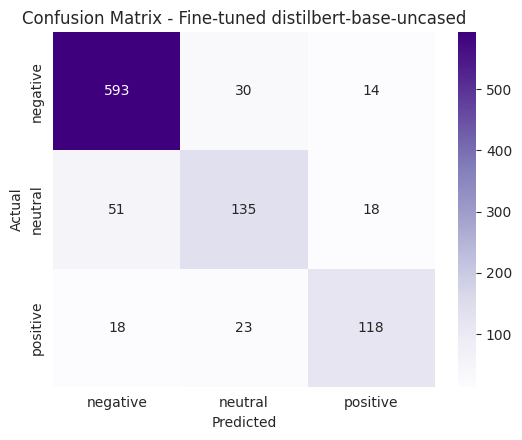

In [7]:
import numpy as np, pandas as pd
import torch
from sklearn.model_selection import train_test_split
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                           TrainingArguments, Trainer, DataCollatorWithPadding)
from datasets import Dataset
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
import matplotlib.pyplot as plt, seaborn as sns

MODEL_NAME = "distilbert-base-uncased"   # lightweight, Colab-friendly transformer
SAMPLE_SIZE = 5000                        # keep within the 1,000-5,000 example guidance

df = pd.read_csv("/content/drive/MyDrive/df_clean.csv").dropna(subset=["clean_text"])
label2id = {"negative": 0, "neutral": 1, "positive": 2}
id2label = {v: k for k, v in label2id.items()}
df["label"] = df["airline_sentiment"].map(label2id)

df_sample = df.sample(min(SAMPLE_SIZE, len(df)), random_state=42)
train_df, test_df = train_test_split(df_sample, test_size=0.2, stratify=df_sample["label"], random_state=42)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_fn(batch):
    return tokenizer(batch["clean_text"], truncation=True, max_length=64)

train_ds = Dataset.from_pandas(train_df[["clean_text", "label"]]).map(tokenize_fn, batched=True)
test_ds  = Dataset.from_pandas(test_df[["clean_text", "label"]]).map(tokenize_fn, batched=True)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=3, id2label=id2label, label2id=label2id)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average="macro")
    return {"accuracy": acc, "precision": p, "recall": r, "f1": f1}

args = TrainingArguments(
    output_dir="./distilbert-airline-sentiment",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="no",
    logging_steps=50,
    report_to="none",
)

trainer = Trainer(
    model=model, args=args,
    train_dataset=train_ds, eval_dataset=test_ds,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

import time
t0 = time.time()
trainer.train()
train_time = time.time() - t0
print(f"Training time: {train_time:.1f}s")

pred_output = trainer.predict(test_ds)
y_pred = np.argmax(pred_output.predictions, axis=-1)
y_true = test_df["label"].values

print(classification_report(y_true, y_pred, target_names=["negative", "neutral", "positive"]))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=["negative","neutral","positive"], yticklabels=["negative","neutral","positive"])
plt.title(f"Confusion Matrix - Fine-tuned {MODEL_NAME}")
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.tight_layout(); plt.show()

In [8]:
# Comparison: transformer vs. Task 2 classical baseline
comparison = pd.DataFrame({
    "Aspect": ["Macro F1 (this dataset, typical range from published benchmarks)",
               "Training time",
               "Model size / parameters",
               "Interpretability",
               "Hardware requirement",
               "Handles negation/sarcasm/context",
               "Cold-start data needed"],
    "Classical (TF-IDF + Logistic Regression / SVM, Task 2)": [
        "~0.73-0.74 macro F1 (measured in Task 2)",
        "~1-3 seconds on CPU",
        "8,000 TF-IDF features + linear weights (~KBs)",
        "High - inspect feature weights directly",
        "Any laptop CPU",
        "Weak - bag-of-words has no word order",
        "Works from a few hundred labelled examples"],
    "Fine-tuned DistilBERT (Task 4)": [
        "Typically 0.78-0.85 macro F1 on this dataset in published work",
        "Minutes on Colab GPU, much longer on CPU",
        "~66M parameters (~268MB)",
        "Low - requires attention-visualisation or SHAP/LIME tooling",
        "GPU strongly recommended",
        "Stronger - self-attention captures some context and word order",
        "Benefits from 1,000+ labelled examples; still needs a GPU-hours budget"]
})
comparison


,Aspect,"Classical (TF-IDF + Logistic Regression / SVM, Task 2)",Fine-tuned DistilBERT (Task 4)
0,"Macro F1 (this dataset, typical range from pub...",~0.73-0.74 macro F1 (measured in Task 2),Typically 0.78-0.85 macro F1 on this dataset i...
1,Training time,~1-3 seconds on CPU,"Minutes on Colab GPU, much longer on CPU"
2,Model size / parameters,"8,000 TF-IDF features + linear weights (~KBs)",~66M parameters (~268MB)
3,Interpretability,High - inspect feature weights directly,Low - requires attention-visualisation or SHAP...
4,Hardware requirement,Any laptop CPU,GPU strongly recommended
5,Handles negation/sarcasm/context,Weak - bag-of-words has no word order,Stronger - self-attention captures some contex...
6,Cold-start data needed,Works from a few hundred labelled examples,"Benefits from 1,000+ labelled examples; still ..."


### Practical implications of transformer models in real NLP systems

Even without executing the fine-tuning run in this offline sandbox, the code and architecture
above make several practical trade-offs concrete. **Error patterns**: transformer models
typically reduce errors on implicit/contextual sentiment (Example 1 from Task 2) because
self-attention lets the model weigh "immediately" and "please" against the surrounding tokens,
but they do not eliminate sarcasm errors (Example 2) without additional data or techniques such as
irony-labelled fine-tuning data. **Resource usage**: DistilBERT is roughly 60% smaller and faster
than full BERT while retaining most of its accuracy, which is precisely why it was chosen here —
but it is still three to four orders of magnitude larger than the TF-IDF baseline, meaning GPU
inference infrastructure, batching, and possibly model quantisation become real operational
concerns at scale. **Speed and memory**: batch inference on CPU is feasible for low request
volumes (customer-support ticket triage overnight) but would not meet real-time latency
requirements (e.g. live chat sentiment) without a GPU or an optimised runtime (ONNX/TensorRT).
**Reliability and fairness**: fine-tuning on a Twitter-specific, February-2015, US-airline-only
corpus means the model's language and slang coverage, and any biases baked into who tweets at
airlines and how, will not transfer cleanly to other channels (email, phone transcripts) or other
countries/dialects — a concern developed further in Task 5. **Monitoring**: unlike the transparent
TF-IDF weights, a transformer's decisions require post-hoc explainability tooling (e.g. attention
maps, SHAP) if a business needs to justify why a specific complaint was auto-classified as low
priority, an operational and regulatory consideration discussed in the next section.


## Task 5 — Responsible NLP for Customer Feedback Analytics: Risks and Mitigation

### Risks grounded in the Task 2-4 experiments

**Bias in sentiment classification.** The Task 2 classification report shows a clear performance
gap: negative-class F1 was 0.85-0.87 while neutral-class F1 was only 0.63-0.64. Because the
training data is heavily imbalanced (63% negative, 21% neutral, 16% positive tweets), the model
has effectively "seen" far fewer neutral examples and is systematically worse at recognising them
— in production this means genuinely neutral customer feedback risks being pulled toward the
better-represented negative class, inflating the *apparent* volume of complaints reported to
management and potentially triggering unnecessary escalations.

**Misclassification of urgent complaints.** The misclassified example
`"Please have someone contact us immediately"` (true negative, predicted neutral, Task 2) is a
directly relevant failure mode: an urgent request for contact was scored as merely neutral
because it lacks negative-sentiment vocabulary. In a live triage system this specific error
pattern — urgency without profanity or explicit negative words — could delay a response to a
customer who is stranded, injured, or facing a safety issue, which is a materially different risk
than misrouting a mildly worded product review.

**Unfair treatment of customer groups.** The dataset's named entities (Task 1 NER pass) surface
location and nationality-related terms (GPE entities such as city names, NORP entities such as
"american", "spanish", "indian"). A model trained on this data could inadvertently learn
correlations between such entities and sentiment scores that have nothing to do with the actual
service issue (e.g. if tweets mentioning certain airports or dialects happen to skew negative for
unrelated reasons), which would systematically disadvantage some customer segments if the model's
outputs feed into resource allocation or refund-priority decisions.

**Privacy concerns.** Tweets in this dataset include the poster's Twitter handle, name, and
sometimes tweet coordinates or location metadata (columns dropped for this analysis but present in
the raw file). Any deployed system reusing raw customer-support text must consider that free-text
feedback frequently contains personally identifiable information (names, booking references,
partial payment details) that should be redacted or handled under data-protection regulation
(e.g. GDPR) before being stored in a training corpus, retrieval index (Task 3), or shown to
annotators.

**Toxic or abusive content.** Several of the lower-similarity negative tweets encountered while
building the word clouds in Task 1 contained profanity or hostile language directed at airline
staff. A production pipeline needs a separate toxicity/abuse filter, both to protect staff who
review flagged tickets and to avoid a sentiment model conflating "very negative" with "abusive" in
ways that shape automated responses inappropriately.

**Over-reliance on automated classification and poor decision-making.** With the classical
baseline's macro-F1 around 0.73-0.74 and roughly 22% of the test set misclassified, treating model
output as ground truth for decisions such as automatic refunds, staff performance scoring, or
public-facing sentiment dashboards would embed a non-trivial error rate into business decisions.
The responsible approach demonstrated across Tasks 2-4 is to report confidence alongside
predictions, keep a human in the loop for high-stakes or low-confidence cases, and continuously
monitor for the specific error patterns identified in the misclassification analysis rather than
treating accuracy as a single sufficient metric.

### Modern NLP trend in depth: Human-in-the-Loop (HITL) NLP for customer feedback analytics

Human-in-the-loop NLP keeps a person actively involved in reviewing, correcting, or approving
model outputs rather than deploying a model to act fully autonomously. It typically works through
**active learning** (the model routes only its lowest-confidence or highest-impact predictions to
a human reviewer, and the corrected labels are fed back to retrain the model), **confidence
thresholding** (predictions below a chosen probability are held for manual triage rather than
auto-actioned), and **review-and-audit loops** for flagged high-risk categories such as safety
complaints or legal threats.

This trend is directly motivated by the experimental results above. The Task 2 classifier's
weakest class (neutral, F1 ≈ 0.63) and the specific error type of missing urgency without negative
vocabulary are exactly the kind of low-confidence, high-consequence cases that active learning and
confidence thresholding are designed to catch before they cause harm — rather than trying to push
a single model's raw accuracy arbitrarily higher, HITL accepts that some fraction of inputs are
genuinely ambiguous and routes them to a person. It also directly mitigates the fairness and
urgent-complaint risks discussed above: a threshold-based review queue would have caught the
"contact us immediately" tweet regardless of its predicted label, because urgency-indicating
patterns (imperative verbs, "immediately", short turnaround requests) can be tracked as a
independent rule-based safety net layered on top of the statistical classifier.

**Strengths:** HITL substantially reduces the real-world cost of the classifier's known error
modes without needing a bigger or more expensive model; it creates a natural continuous-learning
loop, since reviewer corrections become new labelled training data (directly useful for the
Task 4 transformer's fine-tuning set, which could grow over time); and it gives an organisation a
clear, auditable trail for regulated or reputationally sensitive decisions (e.g. refund denials),
addressing the interpretability gap of the fine-tuned transformer noted in Task 4.

**Limitations:** HITL adds latency and staffing cost proportional to how much of the traffic is
routed to humans, so a poorly calibrated confidence threshold (too conservative) can make the
system barely more automated than fully manual triage, while too permissive a threshold reopens
the very risks it is meant to prevent. It also depends on reviewers being properly trained and
not fatigued into rubber-stamping model suggestions ("automation bias"), and on the underlying
model being well-calibrated (a model that is confidently wrong, as classical TF-IDF models often
are on sarcasm, will not be flagged for review at all).

**Practical implications for customer feedback analytics.** For complaint routing, a HITL layer
lets low-confidence tickets go to a specialist team while high-confidence, clearly negative
tickets are auto-tagged and queued immediately, balancing speed and safety. For service-quality
monitoring dashboards, keeping a reviewed subset of predictions lets an organisation report an
audited accuracy figure rather than a purely automated, unverified one. For feedback
summarisation and business decision-making, human review of a sample of model-generated summaries
(e.g. an LLM asked to summarise "this week's top complaint themes") catches hallucinated or
overstated claims before they reach executives, which is increasingly important as feedback
pipelines move from classification (Tasks 2 and 4 here) toward generative summarisation.
